<a href="https://colab.research.google.com/github/DilshanWMP/DRL-laptop-thermal-management/blob/main/DRL_laptop_thermal_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git config --global user.email "praveenwmd@gmail.com"
!git config --global user.name "DilshanWMP"

!git clone https://github.com/DilshanWMP/DRL-laptop-thermal-management.git

import os
os.chdir('/content/DRL-laptop-thermal-management')

print("✅ Connected to GitHub repo!")

Cloning into 'DRL-laptop-thermal-management'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 515.87 KiB | 8.46 MiB/s, done.
✅ Connected to GitHub repo!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/DRL-laptop-thermal-management/Laptop_Motherboard_Health_Monitoring_Dataset.csv')

print("Dataset loaded successfully!")
print(f"\n=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print(f"\n=== FIRST 5 ROWS ===")
print(df.head())

print(f"\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print(f"\n=== DATA TYPES ===")
print(df.dtypes)

Dataset loaded successfully!

=== DATASET SHAPE ===
Rows: 2000, Columns: 8

=== FIRST 5 ROWS ===
            ModelName   CPUUsage   RAMUsage  Temperature    Voltage  \
0  Dell Inspiron 6880  48.447212  73.770260    59.971364  14.807143   
1   Dell ZenBook 2266  54.725241  25.221819    39.165106  15.727814   
2    Dell Galaxy 5903  26.693319  49.900628    93.052670  17.437338   
3   Dell ZenBook 8084  65.591652  29.603866    92.580189  10.645216   
4  Dell Inspiron 8884  24.395216  25.792754    76.175988  15.325681   

   DiskUsage  FanSpeed ProblemDetected  
0  15.502708      3507    Disk Failure  
1   4.421022      1037      No Problem  
2  25.180064      3244    Disk Failure  
3  57.713538      3731      No Problem  
4  83.788169      2830    Disk Failure  

=== COLUMN NAMES ===
['ModelName', 'CPUUsage', 'RAMUsage', 'Temperature', 'Voltage', 'DiskUsage', 'FanSpeed', 'ProblemDetected']

=== DATA TYPES ===
ModelName           object
CPUUsage           float64
RAMUsage           float64

Check Data Quality

In [6]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
print(df.describe())

print("\n=== UNIQUE VALUES IN ProblemDetected ===")
print(df['ProblemDetected'].value_counts())

=== MISSING VALUES ===
ModelName          0
CPUUsage           0
RAMUsage           0
Temperature        0
Voltage            0
DiskUsage          0
FanSpeed           0
ProblemDetected    0
dtype: int64

=== BASIC STATISTICS ===
          CPUUsage     RAMUsage  Temperature      Voltage    DiskUsage  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000   
mean     50.300210    50.938186    59.763022    15.072214    50.060845   
std      28.909198    28.481887    22.928808     2.878348    29.241174   
min       0.004006     0.002407    20.045716    10.004278     0.153563   
25%      25.399382    27.393268    39.574359    12.594651    23.319083   
50%      51.564640    50.559759    60.571872    15.157480    51.107317   
75%      75.240736    75.009930    78.646903    17.523345    75.659567   
max      99.992228    99.960012    99.976932    19.999478    99.876173   

          FanSpeed  
count  2000.000000  
mean   2987.593000  
std    1129.953471  
min    1000.000000 

Visualize Distributions

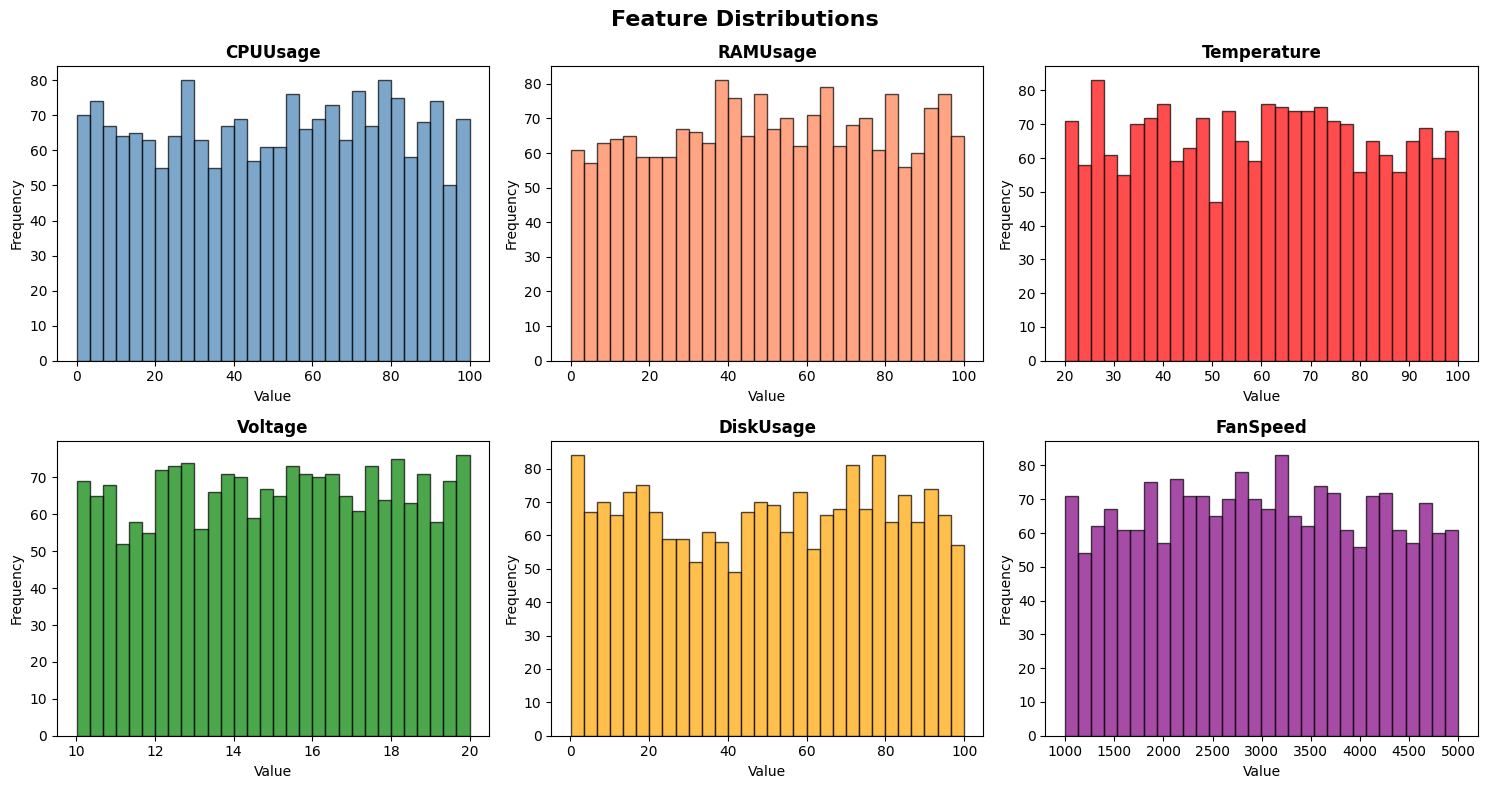

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

features = ['CPUUsage', 'RAMUsage', 'Temperature', 'Voltage', 'DiskUsage', 'FanSpeed']
colors = ['steelblue', 'coral', 'red', 'green', 'orange', 'purple']

for i, (feature, color) in enumerate(zip(features, colors)):
    row, col = i // 3, i % 3
    axes[row, col].hist(df[feature], bins=30, color=color, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(feature, fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

 Temperature vs Fan Speed

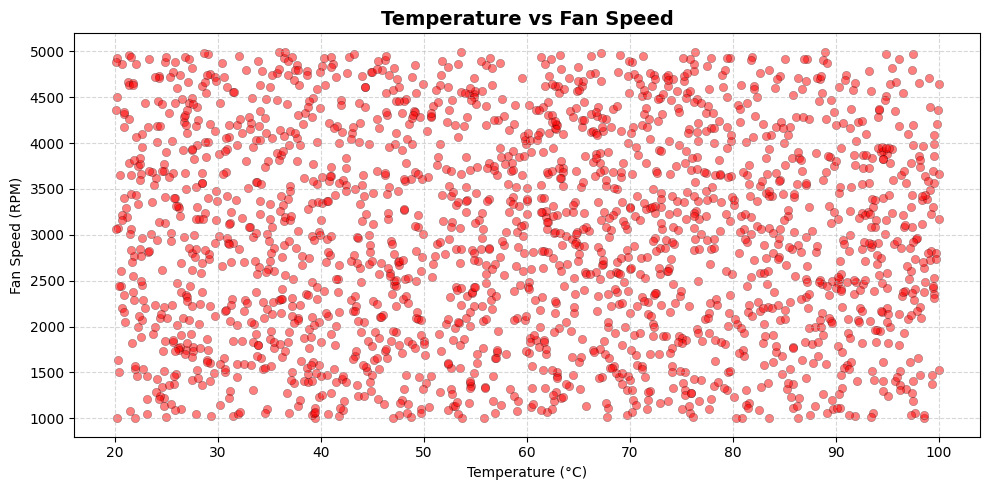

Correlation between Temperature and FanSpeed: -0.0119


In [8]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Temperature'], df['FanSpeed'],
            alpha=0.5, color='red', edgecolors='black', linewidth=0.3)
plt.title('Temperature vs Fan Speed', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Fan Speed (RPM)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Correlation between Temperature and FanSpeed:",
      round(df['Temperature'].corr(df['FanSpeed']), 4))

Correlation Heatmap

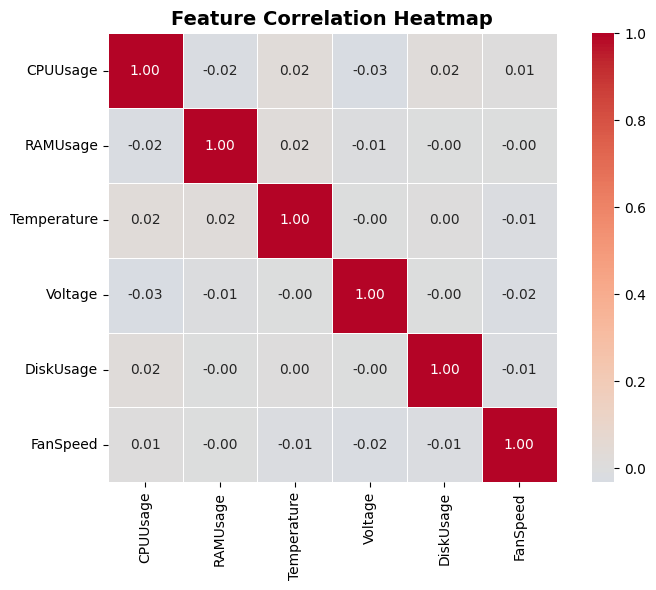

In [9]:
plt.figure(figsize=(8, 6))
numeric_df = df[['CPUUsage', 'RAMUsage', 'Temperature', 'Voltage', 'DiskUsage', 'FanSpeed']]
correlation = numeric_df.corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Temperature Risk Analysis

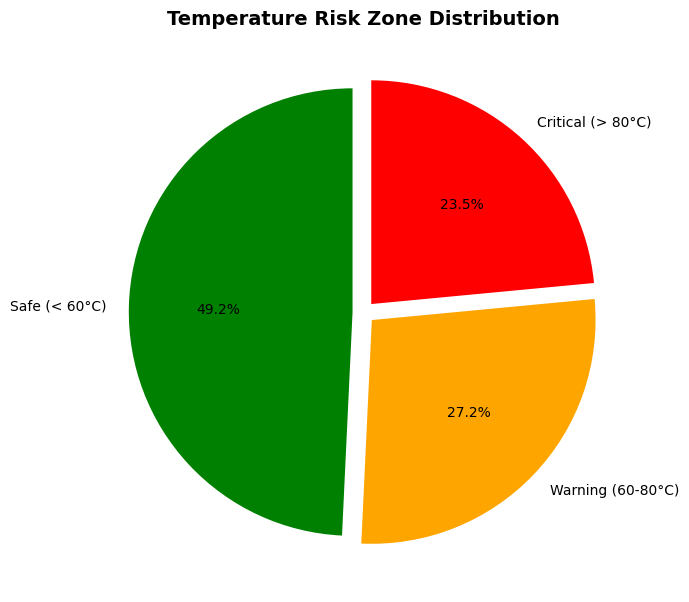


=== TEMPERATURE ZONE COUNTS ===
TempZone
Safe (< 60°C)        985
Warning (60-80°C)    545
Critical (> 80°C)    470
Name: count, dtype: int64


In [10]:
def classify_temp(temp):
    if temp < 60:
        return 'Safe (< 60°C)'
    elif temp < 80:
        return 'Warning (60-80°C)'
    else:
        return 'Critical (> 80°C)'

df['TempZone'] = df['Temperature'].apply(classify_temp)

zone_counts = df['TempZone'].value_counts()
colors_pie = ['green', 'orange', 'red']

plt.figure(figsize=(7, 7))
plt.pie(zone_counts,
        labels=zone_counts.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90,
        explode=(0.05, 0.05, 0.05))
plt.title('Temperature Risk Zone Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== TEMPERATURE ZONE COUNTS ===")
print(zone_counts)

### **Phase 2:Data Preprocessing**

Drop Unnecessary Columns & Encode Labels

In [11]:
# Step 1: Drop ModelName (not useful for training)
df_clean = df.drop(columns=['ModelName'])

print("=== AFTER DROPPING ModelName ===")
print(df_clean.head())
print(f"\nShape: {df_clean.shape}")

=== AFTER DROPPING ModelName ===
    CPUUsage   RAMUsage  Temperature    Voltage  DiskUsage  FanSpeed  \
0  48.447212  73.770260    59.971364  14.807143  15.502708      3507   
1  54.725241  25.221819    39.165106  15.727814   4.421022      1037   
2  26.693319  49.900628    93.052670  17.437338  25.180064      3244   
3  65.591652  29.603866    92.580189  10.645216  57.713538      3731   
4  24.395216  25.792754    76.175988  15.325681  83.788169      2830   

  ProblemDetected           TempZone  
0    Disk Failure      Safe (< 60°C)  
1      No Problem      Safe (< 60°C)  
2    Disk Failure  Critical (> 80°C)  
3      No Problem  Critical (> 80°C)  
4    Disk Failure  Warning (60-80°C)  

Shape: (2000, 8)


Encode ProblemDetected Column

In [12]:
# Step 2: Encode ProblemDetected (text → numbers)
# This converts categories to numbers the model can understand

problem_mapping = {
    'No Problem'  : 0,
    'Overheating' : 1,
    'Memory Leak' : 2,
    'Disk Failure': 3,
    'Power Issue' : 4
}

df_clean['ProblemEncoded'] = df_clean['ProblemDetected'].map(problem_mapping)
df_clean = df_clean.drop(columns=['ProblemDetected'])

print("=== ENCODED DATASET ===")
print(df_clean.head(10))
print(f"\nColumns: {df_clean.columns.tolist()}")

=== ENCODED DATASET ===
    CPUUsage   RAMUsage  Temperature    Voltage  DiskUsage  FanSpeed  \
0  48.447212  73.770260    59.971364  14.807143  15.502708      3507   
1  54.725241  25.221819    39.165106  15.727814   4.421022      1037   
2  26.693319  49.900628    93.052670  17.437338  25.180064      3244   
3  65.591652  29.603866    92.580189  10.645216  57.713538      3731   
4  24.395216  25.792754    76.175988  15.325681  83.788169      2830   
5  22.774119  90.248615    94.711862  12.996791  92.699733      3011   
6  93.613841  13.505777    45.575281  14.631244  47.984458      2570   
7  83.360361   9.684934    89.528878  13.720040  21.871661      2058   
8  18.526864  38.232166    64.916620  17.722543  60.529062      4829   
9  26.071981  36.366956    93.439256  12.326875  78.854244      3841   

            TempZone  ProblemEncoded  
0      Safe (< 60°C)               3  
1      Safe (< 60°C)               0  
2  Critical (> 80°C)               3  
3  Critical (> 80°C)       

Normalize All Features

In [13]:
# Step 3: Normalize features to range [0, 1]
# Neural networks train much better on normalized data

from sklearn.preprocessing import MinMaxScaler
import joblib

# Define which columns to normalize
feature_columns = ['CPUUsage', 'RAMUsage', 'Temperature',
                   'Voltage', 'DiskUsage', 'FanSpeed']

# Create and fit the scaler
scaler = MinMaxScaler()
df_clean[feature_columns] = scaler.fit_transform(df_clean[feature_columns])

print("=== NORMALIZED DATASET ===")
print(df_clean.head())

print("\n=== VALUE RANGES AFTER NORMALIZATION ===")
print(df_clean[feature_columns].describe().loc[['min', 'max']])

# Save scaler for later use (we'll need it to reverse normalization)
import os
save_path = '/content/drive/MyDrive/DRL-laptop-thermal-management/'
os.makedirs(save_path, exist_ok=True)
joblib.dump(scaler, save_path + 'scaler.pkl')
print("\n✅ Scaler saved to Google Drive!")

=== NORMALIZED DATASET ===
   CPUUsage  RAMUsage  Temperature   Voltage  DiskUsage  FanSpeed  \
0  0.484489  0.737991     0.499500  0.480517   0.153918  0.627534   
1  0.547277  0.252301     0.239198  0.572628   0.042793  0.009262   
2  0.266925  0.499194     0.913372  0.743663   0.250961  0.561702   
3  0.655954  0.296140     0.907461  0.064125   0.577201  0.683605   
4  0.243941  0.258013     0.702232  0.532396   0.838672  0.458073   

            TempZone  ProblemEncoded  
0      Safe (< 60°C)               3  
1      Safe (< 60°C)               0  
2  Critical (> 80°C)               3  
3  Critical (> 80°C)               0  
4  Warning (60-80°C)               3  

=== VALUE RANGES AFTER NORMALIZATION ===
     CPUUsage  RAMUsage  Temperature  Voltage  DiskUsage  FanSpeed
min       0.0       0.0          0.0      0.0        0.0       0.0
max       1.0       1.0          1.0      1.0        1.0       1.0

✅ Scaler saved to Google Drive!


Build World Model Training Data

In [14]:
# Goal: Given current state + action → predict next temperature
#
# We simulate "actions" as changes to FanSpeed
# Action 0 = decrease fan (-0.1)
# Action 1 = maintain fan (0)
# Action 2 = increase fan (+0.1)
# ============================================

import numpy as np

# Create action column (simulate random actions taken)
np.random.seed(42)
actions = np.random.choice([-0.1, 0.0, 0.1], size=len(df_clean))
df_clean['Action'] = actions

# Create next_temperature (target variable)
# Physics logic: higher fan action → temperature drops slightly
# This injects realistic behavior into synthetic data
df_clean['Next_Temperature'] = (
    df_clean['Temperature']
    - (actions * 0.15)                          # fan action effect
    + (df_clean['CPUUsage'] * 0.05)             # CPU load heats things up
    - (df_clean['RAMUsage'] * 0.01)             # small RAM effect
    + np.random.normal(0, 0.02, len(df_clean))  # small random noise
).clip(0, 1)  # keep within normalized range

print("=== WORLD MODEL TRAINING DATA ===")
print(df_clean[['CPUUsage', 'RAMUsage', 'Temperature',
                'FanSpeed', 'Action', 'Next_Temperature']].head(10))

print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

=== WORLD MODEL TRAINING DATA ===
   CPUUsage  RAMUsage  Temperature  FanSpeed  Action  Next_Temperature
0  0.484489  0.737991     0.499500  0.627534     0.1          0.534775
1  0.547277  0.252301     0.239198  0.009262    -0.1          0.274958
2  0.266925  0.499194     0.913372  0.561702     0.1          0.903005
3  0.655954  0.296140     0.907461  0.683605     0.1          0.943153
4  0.243941  0.258013     0.702232  0.458073    -0.1          0.736969
5  0.227728  0.902845     0.934130  0.503379    -0.1          0.911540
6  0.936209  0.135091     0.319394  0.392991     0.1          0.332986
7  0.833662  0.096866     0.869287  0.264831     0.0          0.909730
8  0.185250  0.382460     0.561369  0.958448     0.1          0.524413
9  0.260710  0.363800     0.918209  0.711139     0.1          0.903123

Final dataset shape: (2000, 10)
Columns: ['CPUUsage', 'RAMUsage', 'Temperature', 'Voltage', 'DiskUsage', 'FanSpeed', 'TempZone', 'ProblemEncoded', 'Action', 'Next_Temperature']


Split into Train/Test & Save

In [15]:
# 80% training, 20% testing

from sklearn.model_selection import train_test_split

# Features (inputs to world model)
X = df_clean[['CPUUsage', 'RAMUsage', 'Temperature',
              'Voltage', 'DiskUsage', 'FanSpeed', 'Action']].values

# Target (what we want to predict)
y = df_clean['Next_Temperature'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=== DATA SPLIT ===")
print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing samples   : {X_test.shape[0]}")
print(f"Input features    : {X_train.shape[1]}")

# Save processed data
np.save(save_path + 'X_train.npy', X_train)
np.save(save_path + 'X_test.npy',  X_test)
np.save(save_path + 'y_train.npy', y_train)
np.save(save_path + 'y_test.npy',  y_test)

print("\n✅ Preprocessed data saved to Google Drive!")
print("✅ Phase 2 Complete! Ready to build the World Model.")

=== DATA SPLIT ===
Training samples  : 1600
Testing samples   : 400
Input features    : 7

✅ Preprocessed data saved to Google Drive!
✅ Phase 2 Complete! Ready to build the World Model.


### **Phase 3: Build the ANN World Model**

In [16]:
# ============================================
# PHASE 3 - ANN WORLD MODEL
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Check if GPU is available (Colab gives free GPU!)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

✅ Using device: cpu
PyTorch version: 2.11.0+cpu


Load Saved Data & Prepare Tensors

In [17]:
save_path = '/content/drive/MyDrive/DRL-laptop-thermal-management/'

X_train = np.load(save_path + 'X_train.npy')
X_test  = np.load(save_path + 'X_test.npy')
y_train = np.load(save_path + 'y_train.npy')
y_test  = np.load(save_path + 'y_test.npy')

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# Create DataLoaders (feeds data in batches during training)
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("✅ Data loaded and converted to tensors!")
print(f"X_train shape : {X_train_t.shape}")
print(f"y_train shape : {y_train_t.shape}")
print(f"X_test shape  : {X_test_t.shape}")
print(f"y_test shape  : {y_test_t.shape}")

✅ Data loaded and converted to tensors!
X_train shape : torch.Size([1600, 7])
y_train shape : torch.Size([1600, 1])
X_test shape  : torch.Size([400, 7])
y_test shape  : torch.Size([400, 1])


Define the ANN Architecture

In [18]:
# ============================================
# ANN WORLD MODEL ARCHITECTURE
#
#  Input Layer  : 7 features
#                 (CPUUsage, RAMUsage, Temperature,
#                  Voltage, DiskUsage, FanSpeed, Action)
#  Hidden Layer 1: 128 neurons
#  Hidden Layer 2: 64 neurons
#  Hidden Layer 3: 32 neurons
#  Output Layer  : 1 value (Next_Temperature)
# ============================================

class WorldModel(nn.Module):
    def __init__(self):
        super(WorldModel, self).__init__()

        self.network = nn.Sequential(
            # Input → Hidden Layer 1
            nn.Linear(7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),         # prevents overfitting

            # Hidden Layer 1 → Hidden Layer 2
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Hidden Layer 2 → Hidden Layer 3
            nn.Linear(64, 32),
            nn.ReLU(),

            # Hidden Layer 3 → Output
            nn.Linear(32, 1),
            nn.Sigmoid()             # output between 0-1 (normalized temp)
        )

    def forward(self, x):
        return self.network(x)

# Create the model
model = WorldModel().to(device)

# Print model summary
print("=== WORLD MODEL ARCHITECTURE ===")
print(model)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

=== WORLD MODEL ARCHITECTURE ===
WorldModel(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total trainable parameters: 11,393


Train the World Model

In [19]:
# Loss function and optimizer
criterion = nn.MSELoss()                           # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Training settings
EPOCHS = 100
train_losses = []
test_losses  = []

print("=== TRAINING STARTED ===\n")

for epoch in range(EPOCHS):

    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()          # clear old gradients
        predictions = model(X_batch)   # forward pass
        loss = criterion(predictions, y_batch)  # calculate loss
        loss.backward()                # backpropagation
        optimizer.step()               # update weights
        train_loss += loss.item()

    # --- TESTING PHASE ---
    model.eval()
    test_loss = 0.0

    with torch.no_grad():              # no gradient calculation needed
        for X_batch, y_batch in test_loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()

    # Average losses
    avg_train_loss = train_loss / len(train_loader)
    avg_test_loss  = test_loss  / len(test_loader)

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    scheduler.step()

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Test Loss: {avg_test_loss:.6f}")

print("\n✅ Training Complete!")

=== TRAINING STARTED ===

Epoch [ 10/100] | Train Loss: 0.003305 | Test Loss: 0.001208
Epoch [ 20/100] | Train Loss: 0.002169 | Test Loss: 0.000730
Epoch [ 30/100] | Train Loss: 0.001790 | Test Loss: 0.000667
Epoch [ 40/100] | Train Loss: 0.001653 | Test Loss: 0.000651
Epoch [ 50/100] | Train Loss: 0.001508 | Test Loss: 0.000602
Epoch [ 60/100] | Train Loss: 0.001525 | Test Loss: 0.000589
Epoch [ 70/100] | Train Loss: 0.001438 | Test Loss: 0.000571
Epoch [ 80/100] | Train Loss: 0.001318 | Test Loss: 0.000585
Epoch [ 90/100] | Train Loss: 0.001387 | Test Loss: 0.000563
Epoch [100/100] | Train Loss: 0.001385 | Test Loss: 0.000569

✅ Training Complete!


Plot Training Results

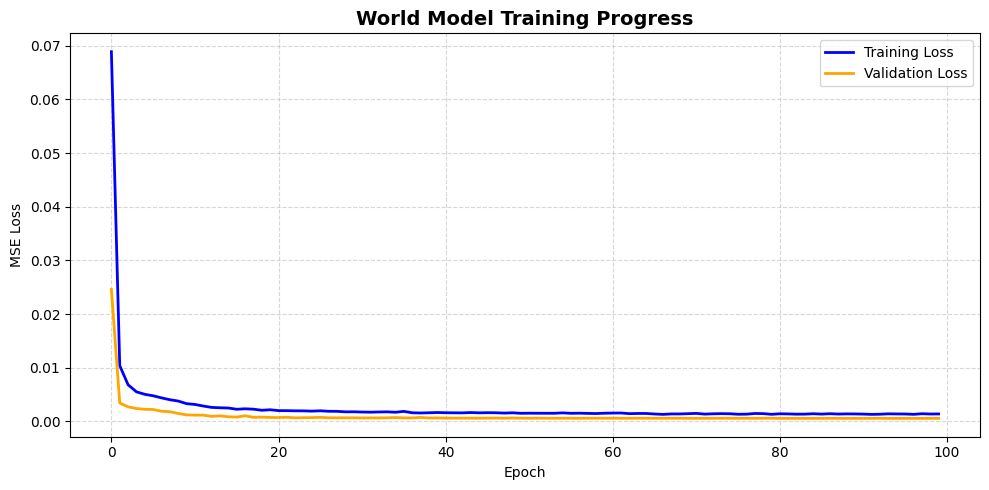

Final Training Loss : 0.001385
Final Test Loss     : 0.000569


In [20]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss',   color='blue',  linewidth=2)
plt.plot(test_losses,  label='Validation Loss', color='orange', linewidth=2)
plt.title('World Model Training Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Final Training Loss : {train_losses[-1]:.6f}")
print(f"Final Test Loss     : {test_losses[-1]:.6f}")

Evaluate & Save the Model

=== WORLD MODEL PERFORMANCE ===
MSE  (lower is better) : 0.000565
MAE  (lower is better) : 0.019582
R²   (higher is better): 0.993098


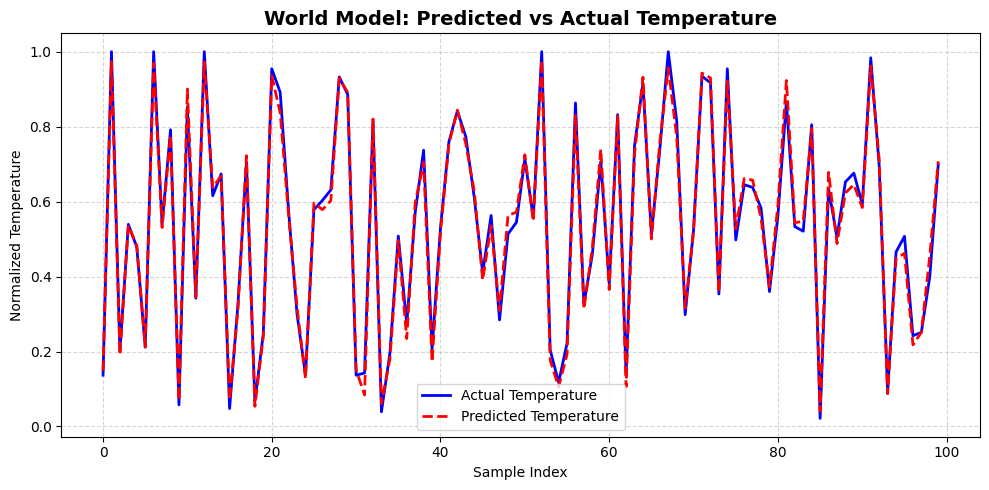


✅ World Model saved to Google Drive!
✅ Phase 3 Complete! Ready to build the RL Environment.


In [21]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).cpu().numpy().flatten()
    y_true = y_test_t.cpu().numpy().flatten()

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("=== WORLD MODEL PERFORMANCE ===")
print(f"MSE  (lower is better) : {mse:.6f}")
print(f"MAE  (lower is better) : {mae:.6f}")
print(f"R²   (higher is better): {r2:.6f}")

# Plot predictions vs actual
plt.figure(figsize=(10, 5))
plt.plot(y_true[:100],  label='Actual Temperature',    color='blue',  linewidth=2)
plt.plot(y_pred[:100],  label='Predicted Temperature', color='red',   linewidth=2, linestyle='--')
plt.title('World Model: Predicted vs Actual Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Normalized Temperature')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Save the trained model
torch.save(model.state_dict(), save_path + 'world_model.pth')
print("\n✅ World Model saved to Google Drive!")
print("✅ Phase 3 Complete! Ready to build the RL Environment.")

### **Phase 4: Build the Custom Gym Environment**

Install Gymnasium

In [22]:
!pip install gymnasium stable-baselines3 -q

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import torch.nn as nn

print("✅ Gymnasium and Stable-Baselines3 installed!")

✅ Gymnasium and Stable-Baselines3 installed!


Rebuild World Model Class & Load Weights

In [23]:
# ============================================
# RELOAD WORLD MODEL
# (We need this inside the environment)
# ============================================

save_path = '/content/drive/MyDrive/DRL-laptop-thermal-management/'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Rebuild the architecture (must match exactly what we trained)
class WorldModel(nn.Module):
    def __init__(self):
        super(WorldModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

# Load saved weights
world_model = WorldModel().to(device)
world_model.load_state_dict(
    torch.load(save_path + 'world_model.pth', map_location=device)
)
world_model.eval()  # set to evaluation mode

print("✅ World Model loaded successfully!")

✅ World Model loaded successfully!


Build the Custom Gym Environment

In [24]:
# ============================================
# CUSTOM LAPTOP THERMAL ENVIRONMENT
#
# This is the "game" the RL agent plays:
#
# STATE  → agent observes sensor readings
# ACTION → agent picks a control action
# REWARD → agent gets score based on outcome
# DONE   → episode ends after 200 steps
# ============================================

class LaptopThermalEnv(gym.Env):

    def __init__(self, world_model, device):
        super(LaptopThermalEnv, self).__init__()

        self.world_model = world_model
        self.device      = device
        self.max_steps   = 200       # each episode = 200 steps
        self.step_count  = 0

        # ----------------------------------------
        # ACTION SPACE — 3 discrete actions:
        # 0 = decrease fan speed
        # 1 = maintain fan speed
        # 2 = increase fan speed
        # ----------------------------------------
        self.action_space = spaces.Discrete(3)

        # ----------------------------------------
        # OBSERVATION SPACE — 5 sensor readings
        # all normalized between 0 and 1
        # [CPUUsage, RAMUsage, Temperature,
        #  Voltage, FanSpeed]
        # ----------------------------------------
        self.observation_space = spaces.Box(
            low   = 0.0,
            high  = 1.0,
            shape = (5,),
            dtype = np.float32
        )

        # Action to fan speed change mapping
        self.action_map = {
            0: -0.1,   # decrease fan
            1:  0.0,   # maintain fan
            2:  0.1    # increase fan
        }

    # ----------------------------------------
    # RESET — called at start of each episode
    # ----------------------------------------
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count = 0

        # Random starting state (simulate different workloads)
        self.state = np.array([
            np.random.uniform(0.1, 0.9),   # CPUUsage
            np.random.uniform(0.1, 0.9),   # RAMUsage
            np.random.uniform(0.2, 0.6),   # Temperature (start safe)
            np.random.uniform(0.0, 1.0),   # Voltage
            np.random.uniform(0.2, 0.8),   # FanSpeed
        ], dtype=np.float32)

        return self.state, {}

    # ----------------------------------------
    # STEP — called every time agent acts
    # ----------------------------------------
    def step(self, action):
        self.step_count += 1

        cpu_usage   = self.state[0]
        ram_usage   = self.state[1]
        temperature = self.state[2]
        voltage     = self.state[3]
        fan_speed   = self.state[4]

        # Get fan delta from action
        fan_delta = self.action_map[action]

        # Update fan speed (clamp between 0 and 1)
        new_fan_speed = float(np.clip(fan_speed + fan_delta, 0.0, 1.0))

        # Predict next temperature using world model
        model_input = torch.FloatTensor([[
            cpu_usage, ram_usage, temperature,
            voltage, 0.5, new_fan_speed,  # DiskUsage fixed at 0.5
            fan_delta                      # Action
        ]]).to(self.device)

        with torch.no_grad():
            next_temp = self.world_model(model_input).item()

        # Simulate CPU load changes (random workload shifts)
        new_cpu = float(np.clip(
            cpu_usage + np.random.uniform(-0.05, 0.05), 0.0, 1.0
        ))
        new_ram = float(np.clip(
            ram_usage + np.random.uniform(-0.03, 0.03), 0.0, 1.0
        ))

        # Update state
        self.state = np.array([
            new_cpu, new_ram, next_temp,
            voltage, new_fan_speed
        ], dtype=np.float32)

        # ----------------------------------------
        # REWARD FUNCTION
        # Goal: keep temp low + save energy
        # ----------------------------------------
        temp_actual = next_temp * 100  # convert back to °C scale

        if temp_actual > 85:
            # Critical overheating — heavy penalty
            reward = -10.0
        elif temp_actual > 70:
            # Warning zone — small penalty
            reward = -2.0
        elif temp_actual < 50:
            # Too cold — slight penalty (wasting energy on high fan)
            reward = 0.5
        else:
            # Safe zone (50–70°C) — positive reward
            reward = 2.0

        # Extra penalty for max fan (wastes energy)
        if new_fan_speed >= 0.95:
            reward -= 0.5

        # Bonus for maintaining good temp with lower fan
        if 50 <= temp_actual <= 65 and new_fan_speed < 0.6:
            reward += 1.0

        # Episode ends after max_steps
        terminated = self.step_count >= self.max_steps
        truncated  = False

        return self.state, reward, terminated, truncated, {}

    # ----------------------------------------
    # RENDER — optional: print current state
    # ----------------------------------------
    def render(self):
        temp_c = self.state[2] * 100
        fan_pct = self.state[4] * 100
        cpu_pct = self.state[0] * 100
        print(f"Step {self.step_count:3d} | "
              f"Temp: {temp_c:.1f}°C | "
              f"Fan: {fan_pct:.1f}% | "
              f"CPU: {cpu_pct:.1f}%")

print("✅ LaptopThermalEnv class defined!")

✅ LaptopThermalEnv class defined!


Test the Environment Manually

In [25]:
# ============================================
# TEST THE ENVIRONMENT MANUALLY
# (Before training, verify it works correctly)
# ============================================

# Create environment
env = LaptopThermalEnv(world_model, device)

# Reset to starting state
state, _ = env.reset()
print("=== ENVIRONMENT TEST ===")
print(f"Initial State: {state}")
print(f"  CPUUsage   : {state[0]:.3f} ({state[0]*100:.1f}%)")
print(f"  RAMUsage   : {state[1]:.3f} ({state[1]*100:.1f}%)")
print(f"  Temperature: {state[2]:.3f} ({state[2]*100:.1f}°C)")
print(f"  Voltage    : {state[3]:.3f}")
print(f"  FanSpeed   : {state[4]:.3f} ({state[4]*100:.1f}%)")

print(f"\nAction Space : {env.action_space}")
print(f"Obs Space    : {env.observation_space}")

# Run 10 random steps
print("\n=== 10 RANDOM STEPS ===")
total_reward = 0

for step in range(10):
    action = env.action_space.sample()   # random action
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward

    action_name = ['Decrease Fan', 'Maintain Fan', 'Increase Fan'][action]
    env.render()
    print(f"         Action: {action_name} | Reward: {reward:.1f}")

print(f"\nTotal Reward over 10 steps: {total_reward:.1f}")
print("\n✅ Environment working correctly!")

=== ENVIRONMENT TEST ===
Initial State: [0.38666773 0.830314   0.42627528 0.18267238 0.28375933]
  CPUUsage   : 0.387 (38.7%)
  RAMUsage   : 0.830 (83.0%)
  Temperature: 0.426 (42.6°C)
  Voltage    : 0.183
  FanSpeed   : 0.284 (28.4%)

Action Space : Discrete(3)
Obs Space    : Box(0.0, 1.0, (5,), float32)

=== 10 RANDOM STEPS ===
Step   1 | Temp: 45.0°C | Fan: 18.4% | CPU: 39.4%
         Action: Decrease Fan | Reward: 0.5
Step   2 | Temp: 44.5°C | Fan: 28.4% | CPU: 42.2%
         Action: Increase Fan | Reward: 0.5
Step   3 | Temp: 44.3°C | Fan: 38.4% | CPU: 39.3%
         Action: Increase Fan | Reward: 0.5
Step   4 | Temp: 45.3°C | Fan: 38.4% | CPU: 41.1%
         Action: Maintain Fan | Reward: 0.5
Step   5 | Temp: 48.0°C | Fan: 28.4% | CPU: 40.3%
         Action: Decrease Fan | Reward: 0.5
Step   6 | Temp: 49.2°C | Fan: 28.4% | CPU: 44.7%
         Action: Maintain Fan | Reward: 0.5
Step   7 | Temp: 50.6°C | Fan: 28.4% | CPU: 42.2%
         Action: Maintain Fan | Reward: 3.0
Step   8 |

Validate with Stable-Baselines3 Checker

In [26]:
# ============================================
# VALIDATE ENVIRONMENT WITH SB3 CHECKER
# This confirms our env is correctly formatted
# ============================================

from stable_baselines3.common.env_checker import check_env

env_check = LaptopThermalEnv(world_model, device)
check_env(env_check, warn=True)

print("✅ Environment passed all validation checks!")
print("✅ Phase 4 Complete! Ready to train the DRL Agent.")

✅ Environment passed all validation checks!
✅ Phase 4 Complete! Ready to train the DRL Agent.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### **Phase 5: Train the PPO Agent**

Set Up Training

In [27]:
# TRAIN THE PPO DRL AGENT

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np
import matplotlib.pyplot as plt
import os

save_path = '/content/drive/MyDrive/DRL-laptop-thermal-management/'

# Create the environment
env = LaptopThermalEnv(world_model, device)

print("✅ Environment ready for PPO training!")
print(f"Action space : {env.action_space}")
print(f"Obs space    : {env.observation_space}")

✅ Environment ready for PPO training!
Action space : Discrete(3)
Obs space    : Box(0.0, 1.0, (5,), float32)


Custom Callback to Track Training

In [28]:
# ============================================
# CUSTOM CALLBACK
# Tracks reward after every episode
# so we can plot learning progress
# ============================================

class TrainingCallback(BaseCallback):

    def __init__(self, verbose=0):
        super(TrainingCallback, self).__init__(verbose)
        self.episode_rewards  = []
        self.episode_lengths  = []
        self.current_rewards  = 0
        self.current_length   = 0
        self.episode_count    = 0

    def _on_step(self) -> bool:
        # Accumulate reward each step
        self.current_rewards += self.locals['rewards'][0]
        self.current_length  += 1

        # When episode ends, save totals
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_rewards)
            self.episode_lengths.append(self.current_length)
            self.episode_count   += 1
            self.current_rewards  = 0
            self.current_length   = 0

            # Print every 50 episodes
            if self.episode_count % 50 == 0:
                avg_reward = np.mean(self.episode_rewards[-50:])
                print(f"Episode {self.episode_count:4d} | "
                      f"Avg Reward (last 50): {avg_reward:.2f}")
        return True

callback = TrainingCallback()
print("✅ Training callback ready!")

✅ Training callback ready!


Create & Train PPO Agent

In [29]:
# ============================================
# CREATE PPO AGENT
#
# PPO (Proximal Policy Optimization) is one
# of the best RL algorithms for this type
# of continuous control problem.
#
# policy     = "MlpPolicy" (neural network)
# learning_rate = how fast agent updates
# n_steps    = steps before each update
# batch_size = samples per gradient update
# n_epochs   = update passes per batch
# gamma      = discount factor (future rewards)
# ============================================

model_ppo = PPO(
    policy        = "MlpPolicy",
    env           = env,
    learning_rate = 0.0003,
    n_steps       = 2048,
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 0.99,
    verbose       = 0,
    tensorboard_log = None
)

print("=== PPO AGENT ARCHITECTURE ===")
print(model_ppo.policy)

print("\n=== STARTING TRAINING ===")
print("Training for 200,000 steps — this may take 5–10 minutes...\n")

# TRAIN!
model_ppo.learn(
    total_timesteps = 200_000,
    callback        = callback,
    progress_bar    = True
)

print("\n✅ PPO Training Complete!")

# Save trained agent
model_ppo.save(save_path + 'ppo_thermal_agent')
print("✅ PPO Agent saved to Google Drive!")

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

=== PPO AGENT ARCHITECTURE ===
ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=5, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=5, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=3, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)

=== STARTING TRAINING ===
Training for 200,000 steps — this may take 5–10 minutes...



Episode   50 | Avg Reward (last 50): -1574.95

Episode  100 | Avg Reward (last 50): -1470.36

...

Episode  850 | Avg Reward (last 50): -696.12

Episode  900 | Avg Reward (last 50): -767.27

Episode  950 | Avg Reward (last 50): -604.45

Episode 1000 | Avg Reward (last 50): -747.01


✅ PPO Training Complete!
✅ PPO Agent saved to Google Drive!


Plot Learning Curve

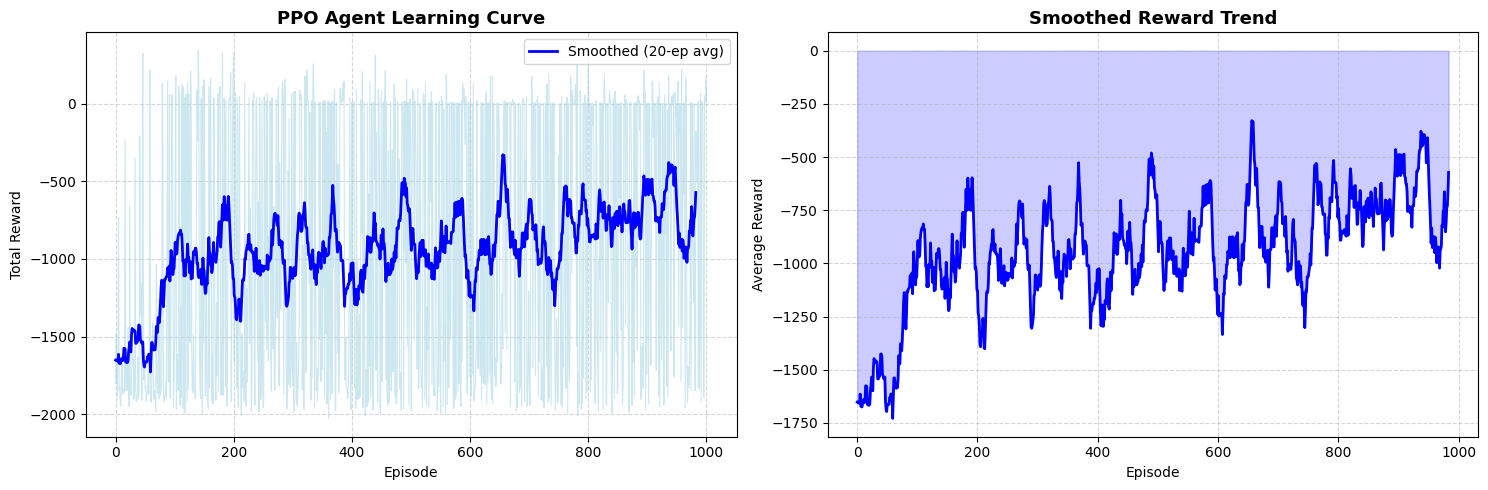

Total episodes trained : 1003
First 20 ep avg reward : -1652.22
Last  20 ep avg reward : -572.38
Improvement            : +1079.85


In [30]:
# ============================================
# PLOT LEARNING CURVE
# Shows how agent improves over time
# ============================================

rewards = callback.episode_rewards

# Smooth rewards with rolling average
def moving_average(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

smoothed = moving_average(rewards, window=20)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw rewards
axes[0].plot(rewards, color='lightblue', alpha=0.6, linewidth=0.8)
axes[0].plot(smoothed, color='blue', linewidth=2, label='Smoothed (20-ep avg)')
axes[0].set_title('PPO Agent Learning Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Rolling average only
axes[1].plot(smoothed, color='blue', linewidth=2)
axes[1].fill_between(range(len(smoothed)), smoothed, alpha=0.2, color='blue')
axes[1].set_title('Smoothed Reward Trend', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Average Reward')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Total episodes trained : {len(rewards)}")
print(f"First 20 ep avg reward : {np.mean(rewards[:20]):.2f}")
print(f"Last  20 ep avg reward : {np.mean(rewards[-20:]):.2f}")
improvement = np.mean(rewards[-20:]) - np.mean(rewards[:20])
print(f"Improvement            : {improvement:+.2f}")

Test the Trained Agent

In [31]:
# ============================================
# TEST THE TRAINED AGENT
# Run 5 full episodes and see how it performs
# ============================================

print("=== TESTING TRAINED PPO AGENT ===\n")

test_env = LaptopThermalEnv(world_model, device)

all_temps    = []
all_rewards  = []
all_actions  = []

action_names = ['Decrease Fan', 'Maintain Fan', 'Increase Fan']

for episode in range(5):
    state, _ = test_env.reset()
    episode_reward = 0
    episode_temps  = []
    episode_actions = []

    for step in range(200):
        # Agent picks action (deterministic=True = no randomness)
        action, _ = model_ppo.predict(state, deterministic=True)
        state, reward, terminated, truncated, _ = test_env.step(int(action))

        episode_reward += reward
        episode_temps.append(state[2] * 100)    # convert to °C
        episode_actions.append(int(action))

        if terminated or truncated:
            break

    all_temps.append(episode_temps)
    all_rewards.append(episode_reward)
    all_actions.append(episode_actions)

    avg_temp = np.mean(episode_temps)
    max_temp = np.max(episode_temps)

    # Count action distribution
    dec = episode_actions.count(0)
    mnt = episode_actions.count(1)
    inc = episode_actions.count(2)

    print(f"Episode {episode+1}: "
          f"Reward={episode_reward:.1f} | "
          f"Avg Temp={avg_temp:.1f}°C | "
          f"Max Temp={max_temp:.1f}°C | "
          f"Actions: ↓{dec} →{mnt} ↑{inc}")

print(f"\nMean Reward across 5 episodes: {np.mean(all_rewards):.2f}")

=== TESTING TRAINED PPO AGENT ===

Episode 1: Reward=2.5 | Avg Temp=14.2°C | Max Temp=41.2°C | Actions: ↓0 →0 ↑200
Episode 2: Reward=0.5 | Avg Temp=17.5°C | Max Temp=41.2°C | Actions: ↓0 →0 ↑200
Episode 3: Reward=1.0 | Avg Temp=15.5°C | Max Temp=50.0°C | Actions: ↓0 →0 ↑200
Episode 4: Reward=-1711.5 | Avg Temp=86.5°C | Max Temp=94.8°C | Actions: ↓0 →0 ↑200
Episode 5: Reward=-1423.5 | Avg Temp=83.6°C | Max Temp=95.2°C | Actions: ↓0 →0 ↑200

Mean Reward across 5 episodes: -626.20


Visualize Agent Behavior

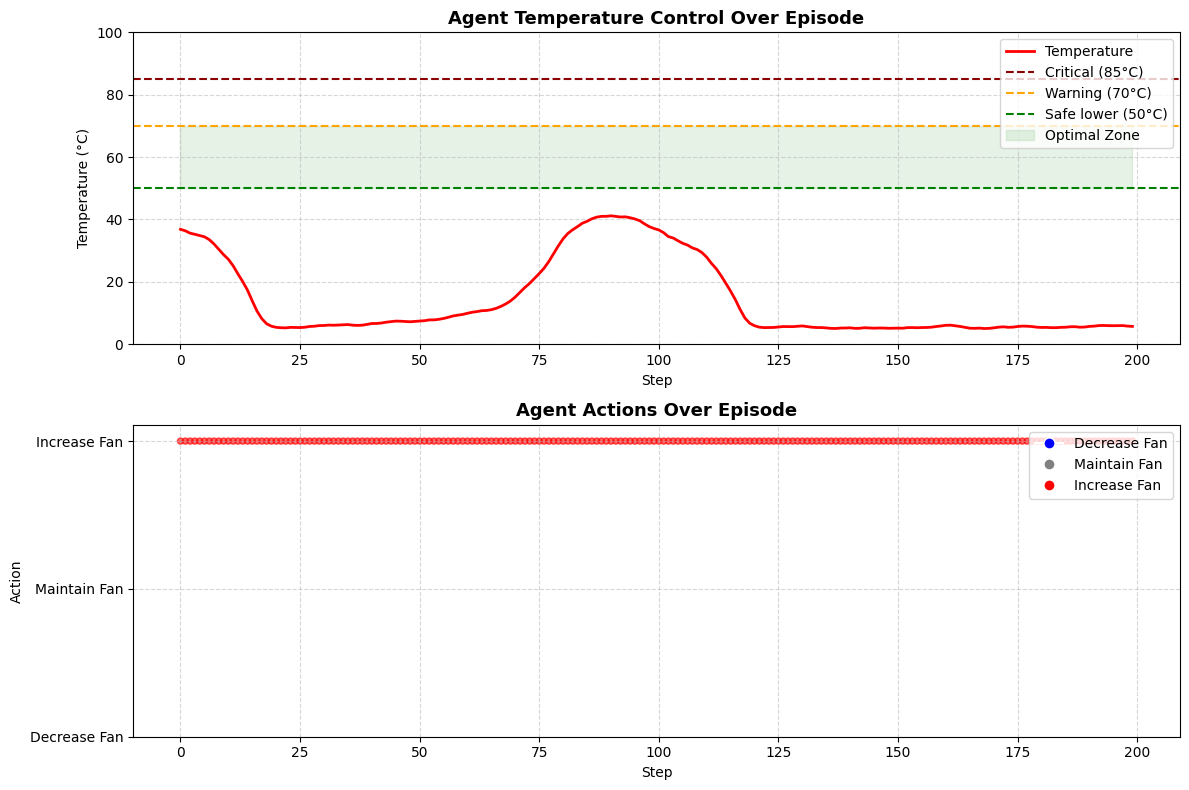

✅ Phase 5 Complete! PPO Agent trained and tested.
✅ Next: Phase 6 — Benchmarking vs baseline controllers


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
# ============================================
# VISUALIZE AGENT BEHAVIOR
# Shows temperature control over one episode
# ============================================

temps   = all_temps[0]
actions = all_actions[0]
steps   = range(len(temps))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Temperature over time
axes[0].plot(steps, temps, color='red', linewidth=2, label='Temperature')
axes[0].axhline(y=85, color='darkred',  linestyle='--', linewidth=1.5, label='Critical (85°C)')
axes[0].axhline(y=70, color='orange',   linestyle='--', linewidth=1.5, label='Warning (70°C)')
axes[0].axhline(y=50, color='green',    linestyle='--', linewidth=1.5, label='Safe lower (50°C)')
axes[0].fill_between(steps, 50, 70, alpha=0.1, color='green', label='Optimal Zone')
axes[0].set_title('Agent Temperature Control Over Episode', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_ylim(0, 100)

# Action distribution
action_colors = ['blue', 'gray', 'red']
action_labels = ['Decrease Fan', 'Maintain Fan', 'Increase Fan']

axes[1].scatter(steps, actions,
                c=[action_colors[a] for a in actions],
                alpha=0.6, s=20)
axes[1].set_title('Agent Actions Over Episode', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Action')
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(action_labels)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Add legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Decrease Fan'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Maintain Fan'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',  markersize=8, label='Increase Fan'),
]
axes[1].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print("✅ Phase 5 Complete! PPO Agent trained and tested.")
print("✅ Next: Phase 6 — Benchmarking vs baseline controllers")